In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [58]:
#read the dataset
df=pd.read_csv('height-weight.csv')

In [59]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


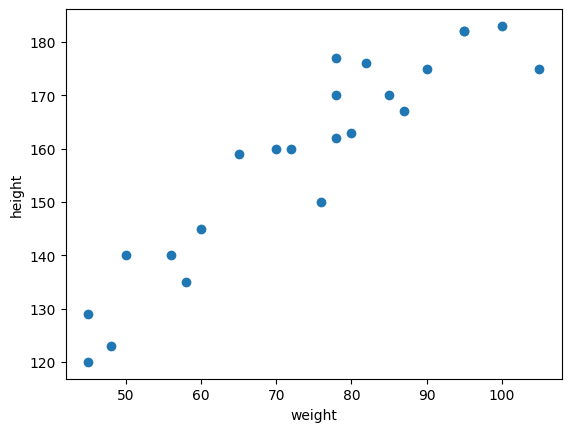

In [60]:
plt.scatter(df.Weight,df.Height)
plt.xlabel('weight')
plt.ylabel('height')
plt.show()

Problem Statement:
I want to predict height based on weight

In [61]:
#divide the data into x and y
X=df[['Weight']]
y=df['Height']

In [62]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [63]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [64]:
#train test split
from sklearn.model_selection import train_test_split


In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1)

In [66]:
#scaling(optional)>>standardization>>fit transform on train data and transform on test data
#we can't use fit transform for the test data, it will cause data leakage
#in most of the ML model  Standard Scaler is used as it deals with the normal distribution

In [67]:
from sklearn.preprocessing import StandardScaler

In [68]:
scaler=StandardScaler()

In [69]:
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [71]:
#scaling should be done always after train test split
#target variables shouldn't be scaled
#avoid scaling categorical features
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

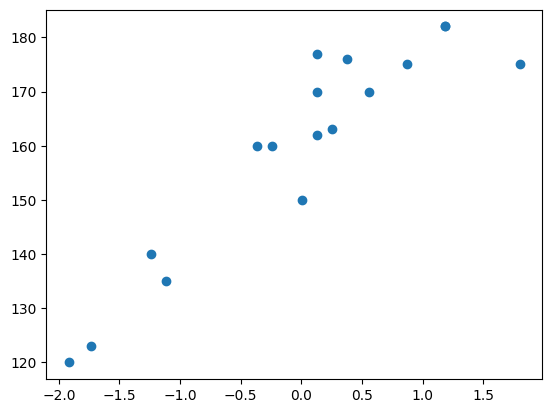

In [72]:
plt.scatter(X_train,y_train)

In [73]:
#model training
from sklearn.linear_model import LinearRegression

In [74]:
#linear regression parameter
#fit_intercept >> the best fit line will have intercept, by default it is true
#copy_X> copy the original X_train and the build the model, it will not modify the original data
#n_jobs>>-1 means using all the processors


In [75]:
regression=LinearRegression()

In [76]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [77]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [78]:
regression.coef_ #slope

array([17.7307072])

In [79]:
regression.intercept_ 

np.float64(160.0)

In [80]:
#prediction on the test data
#y_pred=160+17.73x
y_pred=regression.predict(X_test)

In [81]:
#prediction on train data
regression.predict(X_train)

array([166.65863288, 153.47066096, 129.29271243, 160.06464692,
       164.46063756, 175.45061417, 140.28268904, 169.95562586,
       125.99571945, 162.26264224, 155.66865628, 138.08469371,
       162.26264224, 180.94560247, 191.93557907, 180.94560247,
       162.26264224])

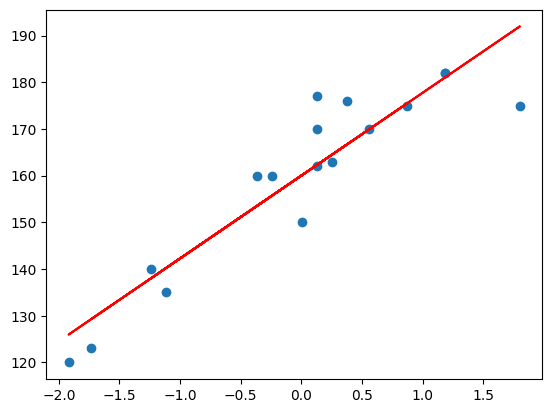

In [82]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

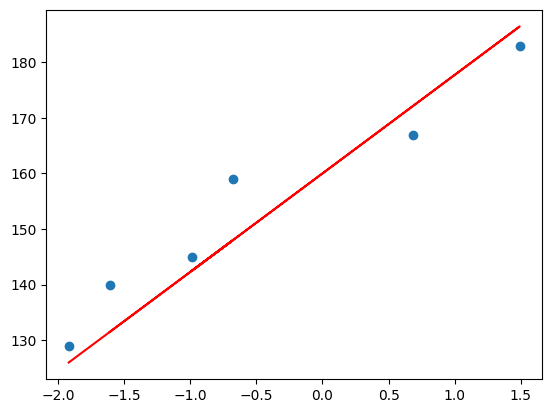

In [83]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,color='red')

In [84]:
#performance metrices
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [85]:
mean_absolute_error(y_test,y_pred)

5.608571289304838

In [86]:
mean_squared_error(y_test,y_pred)

41.285662830455514

In [88]:
r2_score(y_test,y_pred) #r square

0.8721036174256606

In [89]:
#adjusted r square
rsq=r2_score(y_test,y_pred)

In [90]:
1-(1-rsq)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8401295217820757

In [91]:
#assumption
#X-y should have linear relationship
#Observation should have no relation
#error should have constant variation
#error should be normally distributed
#features among themself should be least related

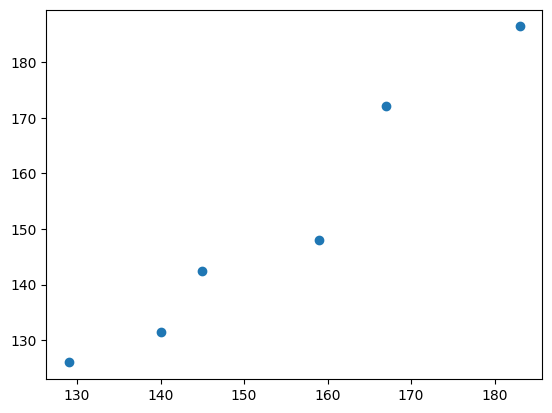

In [94]:
plt.scatter(y_test, y_pred)
#to check if y_test and its prediction aligns

In [95]:
#error should have constant variation
#error should be normally distributed

In [96]:
error = y_test-y_pred
error

20     3.004281
17    11.024327
3      2.519316
13    -3.440591
19    -5.153621
16     8.509292
Name: Height, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8048\464779861.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


<Axes: xlabel='Height', ylabel='Density'>

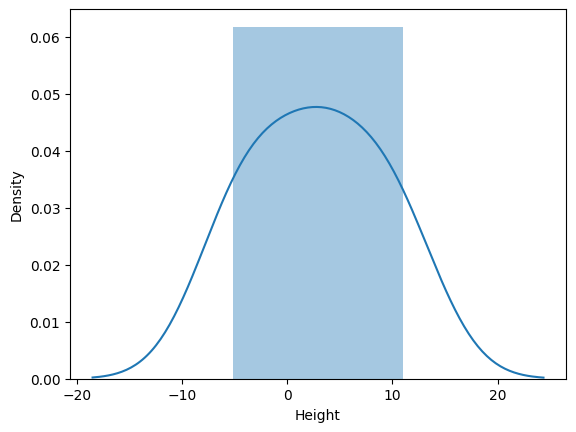

In [97]:
import seaborn as sns
sns.distplot(error)

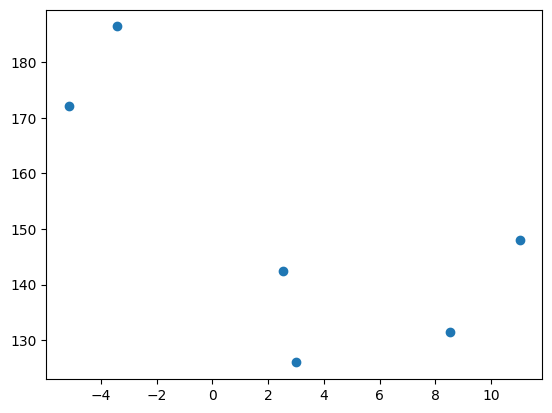

In [98]:
#to check constant variance
plt.scatter(error, y_pred)